In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Colab/titanic.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/Colab/Titanic')

print("Extraction completed!")
print(os.listdir('/content/drive/MyDrive/Colab/Titanic'))

Extraction completed!
['gender_submission.csv', 'test.csv', 'train.csv']


In [4]:
import pandas as pd

train = pd.read_csv('/content/drive/MyDrive/Colab/Titanic/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab/Titanic/test.csv')

print("Train data:")
display(train.head())

print("Test data:")
display(test.head())

Train data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Test data:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nColumns:")
print(train.columns.tolist())

print("\nMissing values:")
print(train.isnull().sum())

Train shape: (891, 12)
Test shape: (418, 11)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# Separate input features and target

X = train.drop('Survived', axis=1)
y = train['Survived']

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Input features:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Target:
Survived


In [7]:
X = X[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

test_X = test[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

print(X.head())

   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S


In [8]:
# Check missing values
print(X.isnull().sum())

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


In [9]:
# Fill missing Age
X['Age'] = X['Age'].fillna(X['Age'].median())
test_X['Age'] = test_X['Age'].fillna(X['Age'].median())

# Fill missing Fare
X['Fare'] = X['Fare'].fillna(X['Fare'].median())
test_X['Fare'] = test_X['Fare'].fillna(X['Fare'].median())

# Fill missing Embarked
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])
test_X['Embarked'] = test_X['Embarked'].fillna(X['Embarked'].mode()[0])

print("Missing values handled!")

Missing values handled!


/tmp/ipykernel_2361/3686449344.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_X['Age'] = test_X['Age'].fillna(X['Age'].median())
/tmp/ipykernel_2361/3686449344.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_X['Fare'] = test_X['Fare'].fillna(X['Fare'].median())
/tmp/ipykernel_2361/3686449344.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

In [10]:
X = pd.get_dummies(
    X,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

test_X = pd.get_dummies(
    test_X,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

# Make both datasets have the same columns
X, test_X = X.align(
    test_X,
    join='left',
    axis=1,
    fill_value=0
)

print(X.head())
print("\nFeatures after encoding:")
print(X.columns.tolist())

   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True

Features after encoding:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [13]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.8044692737430168
Accuracy percentage: 80.44692737430168 %


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[98 12]
 [23 46]]


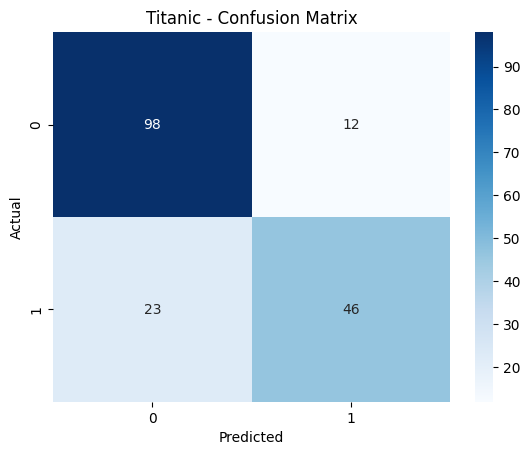

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Titanic - Confusion Matrix')
plt.show()

In [18]:
print("Model Coefficients:")
print(model.coef_)

print("\nModel Intercept:")
print(model.intercept_)

Model Coefficients:
[[-1.09047604e+00 -3.84640032e-02 -2.43809393e-01 -7.14964874e-02
   2.25511171e-03 -2.55575510e+00  2.78320035e-01 -3.81616487e-01]]

Model Intercept:
[4.98134887]


In [19]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(feature_importance)

      Feature  Coefficient
6  Embarked_Q     0.278320
4        Fare     0.002255
1         Age    -0.038464
3       Parch    -0.071496
2       SibSp    -0.243809
7  Embarked_S    -0.381616
0      Pclass    -1.090476
5    Sex_male    -2.555755


In [20]:
import pandas as pd

new_passenger = pd.DataFrame({
    'Pclass': [1],
    'Age': [25],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [100],
    'Sex_male': [0],
    'Embarked_Q': [0],
    'Embarked_S': [1]
})

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("Passenger is predicted to SURVIVE")
else:
    print("Passenger is predicted NOT TO SURVIVE")

Passenger is predicted to SURVIVE


In [21]:
probability = model.predict_proba(new_passenger)

print("Probability of not surviving:", probability[0][0])
print("Probability of surviving:", probability[0][1])

Probability of not surviving: 0.058791498054698854
Probability of surviving: 0.9412085019453011
